
# Seasonal Agriculture Performance Analysis

## Project Description

This project focuses on analyzing agricultural data collected across different seasons, geographical areas, and farming conditions. The analysis considers factors related to farming practices, environmental conditions, crop production, resource usage, and economic performance.

The project uses data analysis, statistical techniques, and visualization methods to explore how agricultural performance varies across seasons. The analysis aims to identify meaningful patterns, trends, relationships, differences, and unusual observations within the dataset.

The insights obtained from the analysis will be used to develop evidence-based conclusions and recommendations that can support better seasonal agricultural planning and decision-making.

## Key Objectives

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Analyze agricultural performance across different seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal conditions and agricultural outcomes.
6. Compare agricultural activities and performance across different seasons.
7. Analyze variations in resource usage across seasons.
8. Apply suitable statistical and data visualization techniques.
9. Interpret the findings based on evidence from the dataset.
10. Develop meaningful conclusions and data-driven recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

Saving agri.csv to agri (2).csv
Dataset loaded successfully!


In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 4000
Number of Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [7]:
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha             

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0



Duplicate Rows: 0


In [9]:
# Remove duplicate records
df = df.drop_duplicates()

# Check missing values
print("Missing values after cleaning:")
display(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values after cleaning:


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0



Dataset shape after cleaning: (4000, 28)


In [10]:
categorical_columns = [
    'State',
    'District',
    'Crop',
    'Season',
    'Irrigation_Method'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


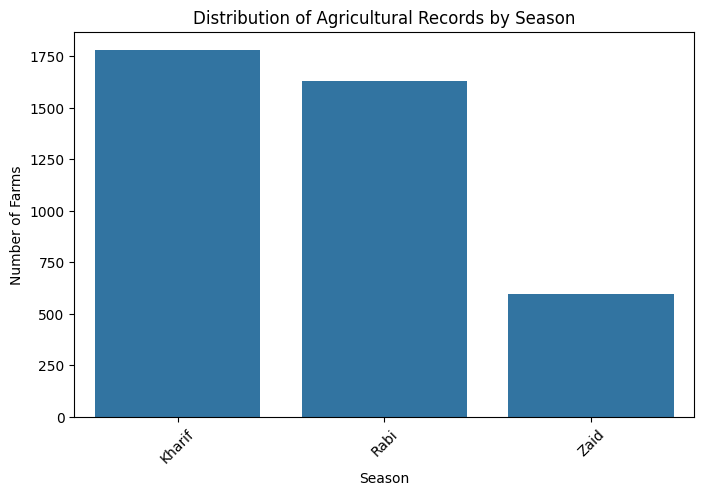

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)
plt.show()

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


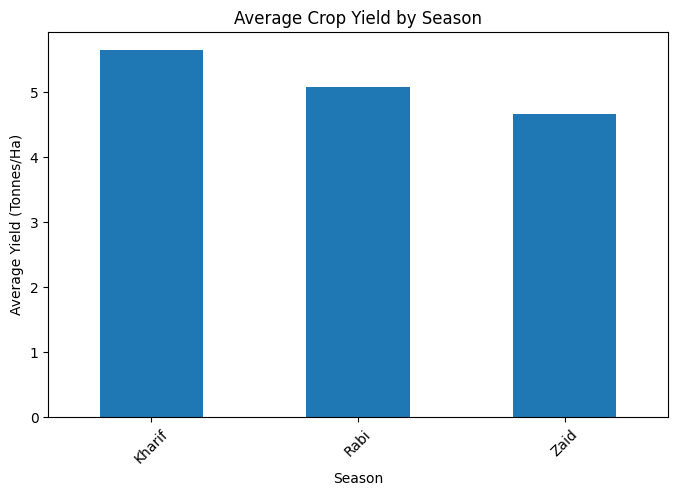

In [12]:
season_yield = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

display(season_yield)

plt.figure(figsize=(8,5))

season_yield.plot(kind='bar')

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


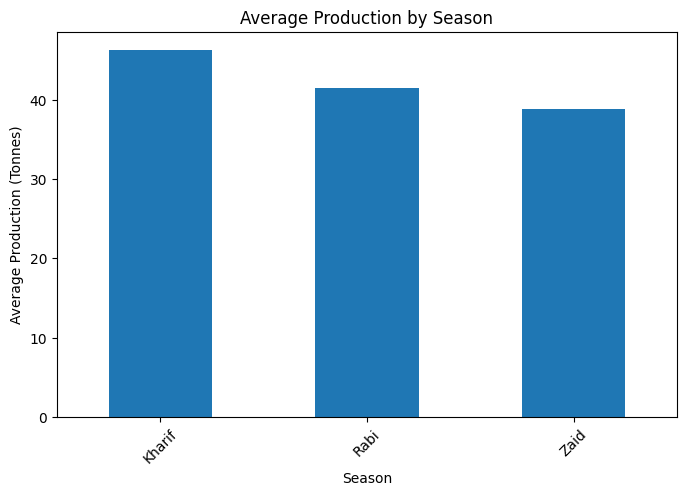

In [13]:
season_production = (
    df.groupby('Season')['Production_Tonnes']
    .mean()
    .sort_values(ascending=False)
)

display(season_production)

plt.figure(figsize=(8,5))

season_production.plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=45)
plt.show()

In [14]:
season_performance = df.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Revenue_INR',
        'Profit_INR',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3'
    ]
].mean()

display(season_performance)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.643973,46.311192,710719.055649,178914.647555,6102.201237,5.891834
Rabi,5.080498,41.486712,601526.048556,87689.470191,5846.987093,5.186122
Zaid,4.665942,38.886111,519171.904040,-24804.824916,6419.893939,4.413239


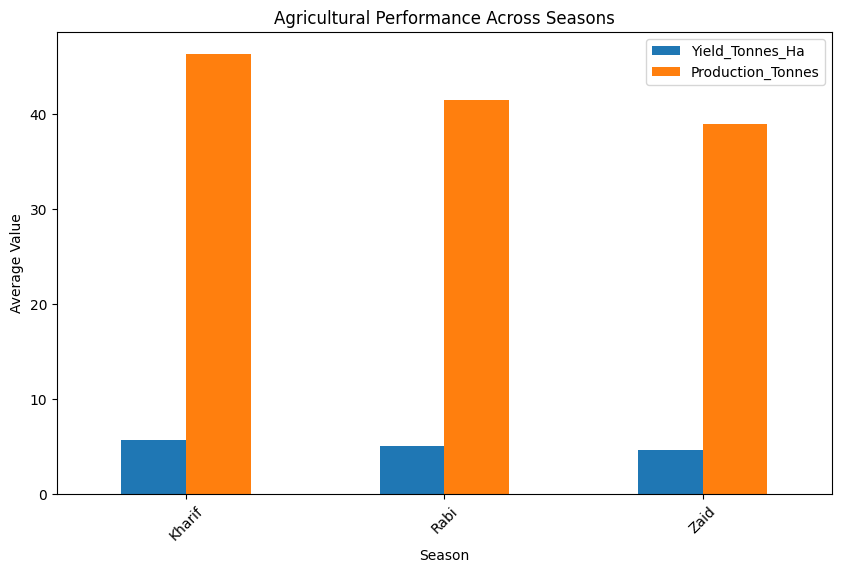

In [15]:
season_performance[
    ['Yield_Tonnes_Ha', 'Production_Tonnes']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Agricultural Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.938746
Maize,2.717130
Rice,2.439413
Wheat,2.109216
Chilli,1.540344
Groundnut,1.317924
Cotton,1.225734
Pulses,0.918198


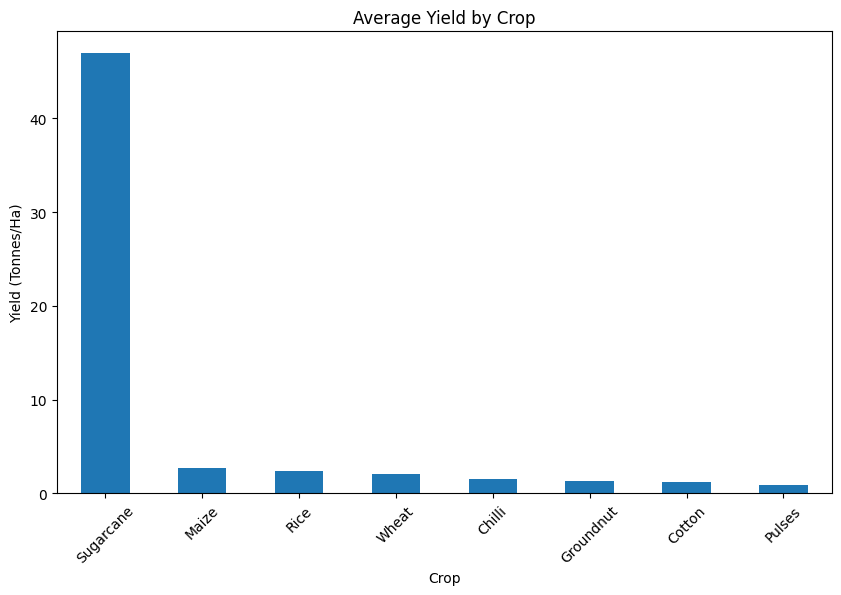

In [16]:
crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

display(crop_yield)

plt.figure(figsize=(10,6))

crop_yield.plot(kind='bar')

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.734493
Gujarat,5.699586
Telangana,5.076810
Maharashtra,5.030333
Madhya Pradesh,5.029654
Tamil Nadu,4.901247
Andhra Pradesh,4.650781


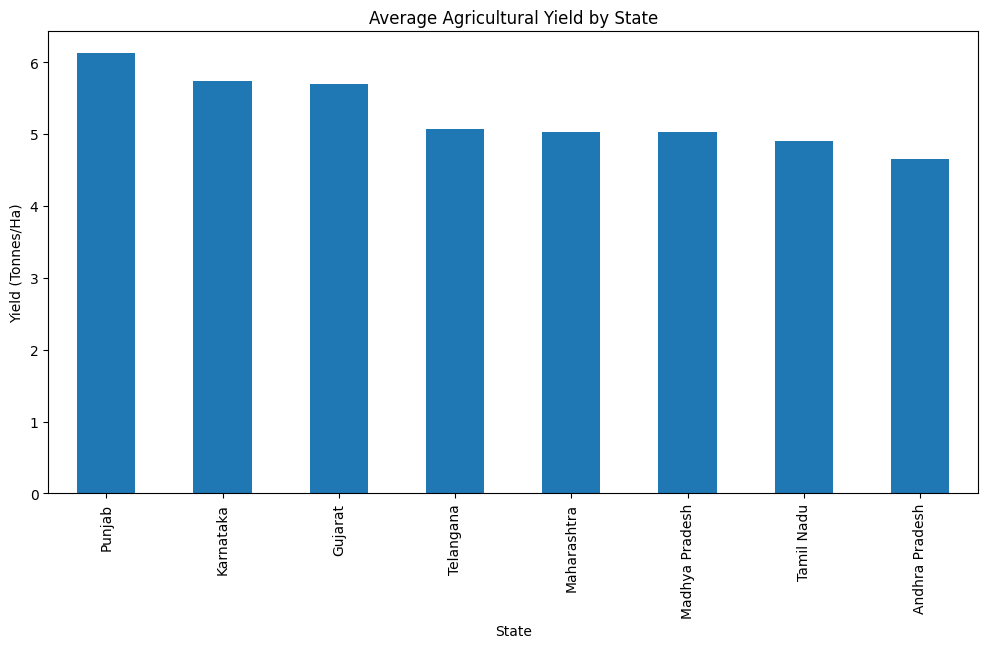

In [17]:
state_performance = (
    df.groupby('State')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

display(state_performance)

plt.figure(figsize=(12,6))

state_performance.plot(kind='bar')

plt.title('Average Agricultural Yield by State')
plt.xlabel('State')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=90)
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731413,1.461615,1.177742
Cotton,1.372804,1.192915,0.951648
Groundnut,1.483646,1.221445,1.037778
Maize,2.966410,2.614913,2.297590
Pulses,1.036063,0.871887,0.652131
Rice,2.707621,2.333680,1.900490
Sugarcane,53.459120,43.940394,38.423922
Wheat,2.255430,2.058814,1.748588


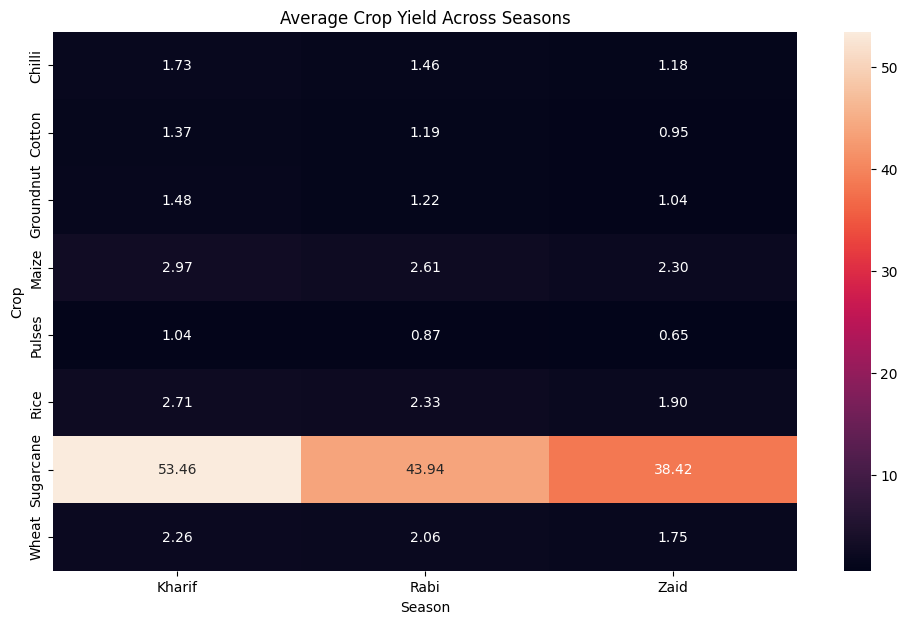

In [18]:
crop_season = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season)

plt.figure(figsize=(12,7))

sns.heatmap(crop_season, annot=True, fmt='.2f')

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

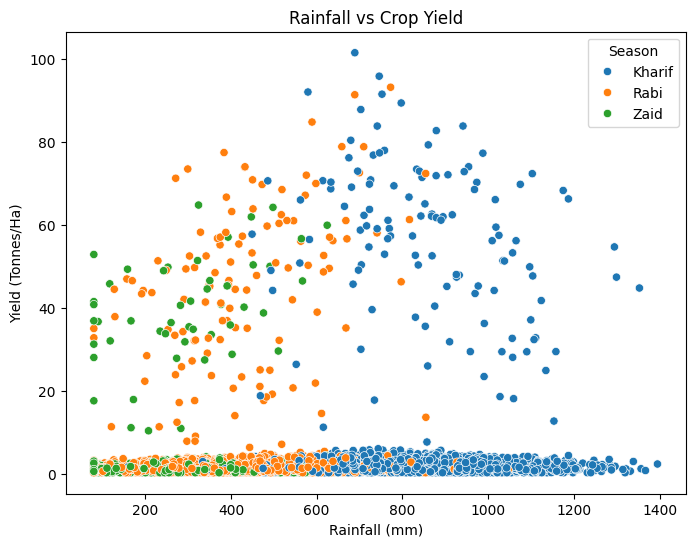

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

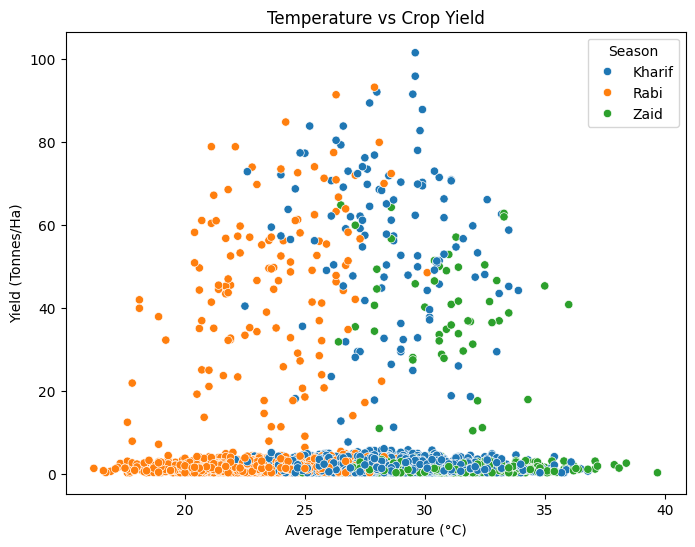

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

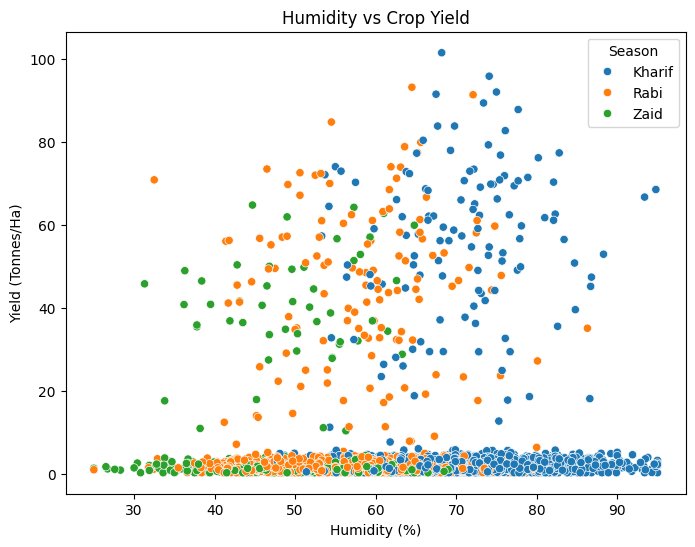

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Humidity vs Crop Yield')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [22]:
seasons = df['Season'].dropna().unique()

season_groups = [
    df[df['Season'] == season]['Yield_Tonnes_Ha']
    for season in seasons
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA F-statistic:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Result: There is a statistically significant difference in yield across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")

ANOVA F-statistic: nan
ANOVA p-value: nan
Result: No statistically significant difference in yield across seasons.


,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


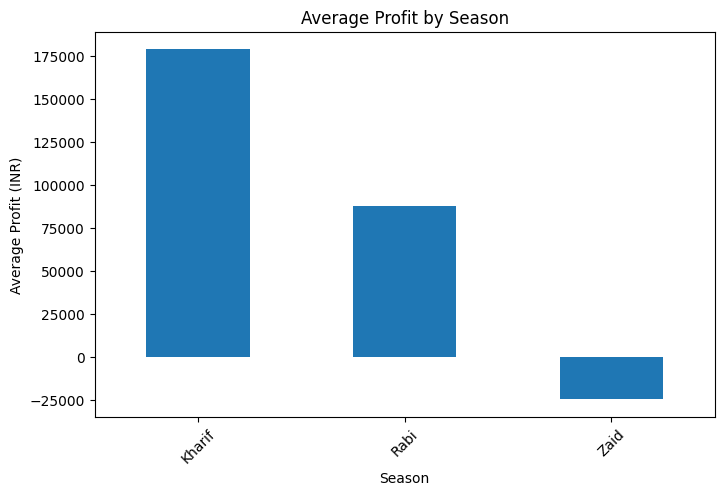

In [23]:
season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

display(season_profit)

plt.figure(figsize=(8,5))

season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


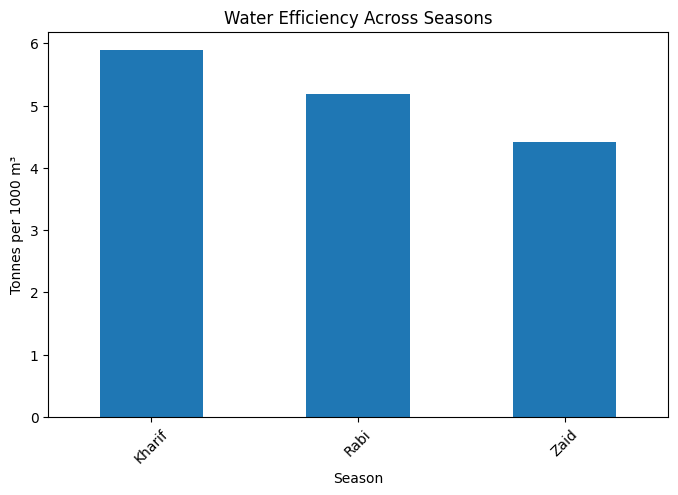

In [24]:
water_efficiency = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

display(water_efficiency)

plt.figure(figsize=(8,5))

water_efficiency.plot(kind='bar')

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.xticks(rotation=45)
plt.show()

In [25]:
print("=" * 60)
print("FINAL PROJECT INSIGHTS")
print("=" * 60)

print("1. Seasonal agricultural performance was compared using yield and production.")

print("2. Crop-wise and state-wise variations in agricultural performance were identified.")

print("3. Environmental factors such as rainfall, temperature and humidity were analyzed.")

print("4. Resource usage including water, fertilizer and pesticide was compared across seasons.")

print("5. Relationships between agricultural variables were investigated using correlation analysis.")

print("6. Statistical analysis was performed to examine differences in yield across seasons.")

print("7. Economic performance was evaluated using cost, revenue and profit.")

print("8. Water efficiency was analyzed to identify differences in resource utilization.")

print("9. The analysis provides evidence-based insights into seasonal agricultural performance.")

print("10. These findings can support improved seasonal agricultural planning.")

FINAL PROJECT INSIGHTS
1. Seasonal agricultural performance was compared using yield and production.
2. Crop-wise and state-wise variations in agricultural performance were identified.
3. Environmental factors such as rainfall, temperature and humidity were analyzed.
4. Resource usage including water, fertilizer and pesticide was compared across seasons.
5. Relationships between agricultural variables were investigated using correlation analysis.
6. Statistical analysis was performed to examine differences in yield across seasons.
7. Economic performance was evaluated using cost, revenue and profit.
8. Water efficiency was analyzed to identify differences in resource utilization.
9. The analysis provides evidence-based insights into seasonal agricultural performance.
10. These findings can support improved seasonal agricultural planning.


# Conclusion

The Seasonal Agriculture Performance Analysis successfully examined agricultural
performance across different seasons using data cleaning, exploratory analysis,
statistical techniques, and visualization.

The analysis covered seasonal yield and production, crop and regional comparisons,
environmental factors, resource usage, economic performance, and water efficiency.

The identified patterns and relationships provide evidence-based insights that can
support better seasonal agricultural planning and decision-making.